In [1]:
import matplotlib
from datascience import *
%matplotlib inline
import matplotlib.pyplot as plots
import numpy as np
plots.style.use('fivethirtyeight')

In [2]:
# Some functions for plotting. You don't have to understand how any
# of the functions in this cell work, since they use things we 
# haven't learned about in DSCI 100.


def resize_window(lim=3.5):
    plots.xlim(-lim, lim)
    plots.ylim(-lim, lim)
    
def draw_line(slope=0, intercept=0, x=make_array(-4, 4), color='#1e90ff'):
    y = x*slope + intercept
    plots.plot(x, y, color=color, lw=3)
    
def draw_vertical_line(x_position, color='black'):
    x = make_array(x_position, x_position)
    y = make_array(-4, 4)
    plots.plot(x, y, color=color, lw=3)
    
def make_correlated_data(r):
    "Make up data for analysis"
    x = np.random.normal(0, 1, 1000)
    z = np.random.normal(0, 1, 1000)
    y = r*x + (np.sqrt(1-r**2))*z
    return x, y

def r_scatter(r):
    """Generate a scatter plot with a correlation approximately r"""
    plots.figure(figsize=(5,5))
    x, y = make_correlated_data(r)
    plots.scatter(x, y, color='darkblue', s=20)
    plots.xlim(-4, 4)
    plots.ylim(-4, 4)
    
def r_table(r):
    """
    Generate a table of 1000 data points with a correlation approximately r
    """
    np.random.seed(8)
    x, y = make_correlated_data(r)
    return Table().with_columns('x', x, 'y', y)

# Lecture 30 Linear Regression

### Interpreting Relationships
Functions from lecture 29.

In [3]:
def standard_units(x):
    "Convert any array of numbers to standard units."
    return (x - np.average(x)) / np.std(x)

In [4]:
def correlation(t, x, y):
    """t is a table; x and y are column labels"""
    x_in_standard_units = standard_units(t.column(x))
    y_in_standard_units = standard_units(t.column(y))
    return np.average(x_in_standard_units * y_in_standard_units)

### Nonlinearity

Some relationships are not linear so r is not a helpful measurement in establishing the strength of that relationship. 

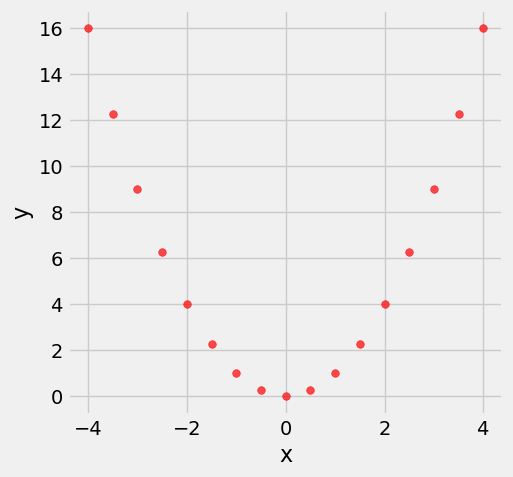

In [5]:
new_x = np.arange(-4, 4.1, 0.5)
nonlinear = Table().with_columns(
        'x', new_x,
        'y', new_x**2
    )
nonlinear.scatter('x', 'y', s=30, color='r')

In [6]:
#Since the relationship is not linear, r makes it appear as if there is no relationship. 
#There is obviously a pattern so r is not helpful.

correlation(nonlinear, 'x', 'y')

0.0

### Outliers

Outliers are individual data points that lie way outside reasonable values. </br>
These can cause r to show no relationship when there is one or a strong relationship when it's weak. 


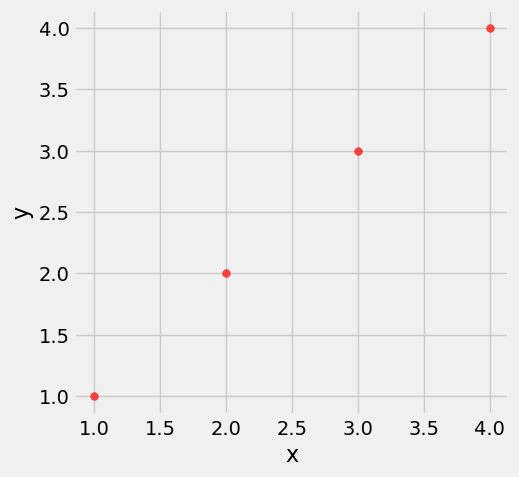

In [7]:
#Example scatter with a very linear relationship. 
line = Table().with_columns(
        'x', make_array(1, 2, 3, 4),
        'y', make_array(1, 2, 3, 4)
    )
line.scatter('x', 'y', s=30, color='r')

In [8]:
correlation(line, 'x', 'y')

1.0

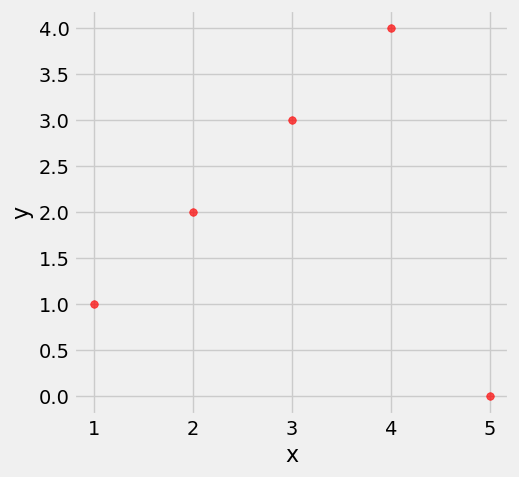

In [9]:
#How is r affected when we insert an outlier far off the trend of the graph.
outlier = Table().with_columns(
        'x', make_array(1, 2, 3, 4, 5),
        'y', make_array(1, 2, 3, 4, 0)
    )
outlier.scatter('x', 'y', s=30, color='r')

In [10]:
#Only one outlier can greatly affect r

correlation(outlier, 'x', 'y')

0.0

### Ecological Correlations

Load in the data for 2014 SAT Data for 51 regions": The 50 States and DC. 
                                   
Describe the table.
                                   
_Note: The scores are the averages across the state._

In [11]:
sat2014 = Table.read_table('sat2014.csv').sort('State')
sat2014

State,Participation Rate,Critical Reading,Math,Writing,Combined
Alabama,6.7,547,538,532,1617
Alaska,54.2,507,503,475,1485
Arizona,36.4,522,525,500,1547
Arkansas,4.2,573,571,554,1698
California,60.3,498,510,496,1504
Colorado,14.3,582,586,567,1735
Connecticut,88.4,507,510,508,1525
Delaware,100,456,459,444,1359
District of Columbia,100,440,438,431,1309
Florida,72.2,491,485,472,1448


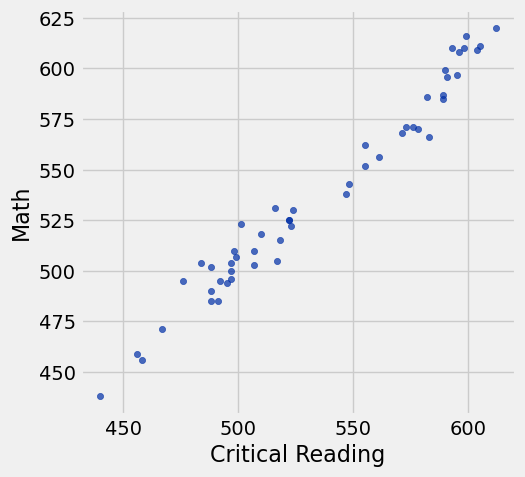

In [12]:
# COMPLETE: Plot the scatter for Reading and Math correlation.
# What would you estimate the correlation coefficient, r, to be?

sat2014.scatter('Critical Reading', 'Math')

In [13]:
# COMPLETE: Use the correlation(t, x, y) function to quantify the relationship between Critical Reading and Math. 

correlation(sat2014, 'Critical Reading', 'Math')

0.98475584110674341

### Be Careful

***QUESTION: What does each point on the scatter plot represent?***



***QUESTION: Is this helpful in predicting an individuals expected score on the SAT? Why or Why Not?***



***QUESTION: Would r be the same if we used individuals?***


In [14]:
# Each region has a different participation because of the requirements of that state regarding the SATs
# QUESTION: If we input the participation rate of the region, what will this function return?

def rate_code(x):
    if x <= 25:
        return 'low'
    elif x <= 75:
        return 'medium'
    else:
        return 'high'

In [15]:
# COMPLETE: Run this function on the Participation Rate column. 

rate_codes = sat2014.apply(rate_code, 'Participation Rate')

In [16]:
# COMPLETE: Create a new table adding the Rate Code column with those values. 

sat2014_rate = sat2014.with_column('Rate Code', rate_codes)
sat2014_rate

State,Participation Rate,Critical Reading,Math,Writing,Combined,Rate Code
Alabama,6.7,547,538,532,1617,low
Alaska,54.2,507,503,475,1485,medium
Arizona,36.4,522,525,500,1547,medium
Arkansas,4.2,573,571,554,1698,low
California,60.3,498,510,496,1504,medium
Colorado,14.3,582,586,567,1735,low
Connecticut,88.4,507,510,508,1525,high
Delaware,100,456,459,444,1359,high
District of Columbia,100,440,438,431,1309,high
Florida,72.2,491,485,472,1448,medium


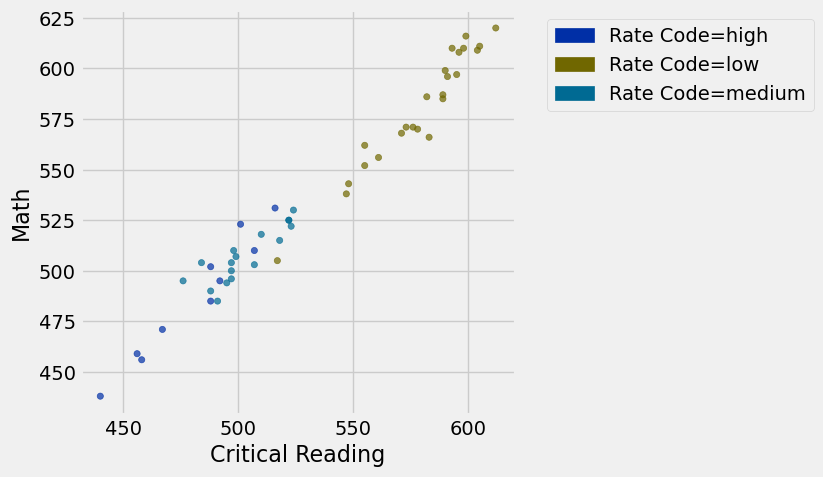

In [17]:
# COMPLETE: View the same scatter with the rate code grouping. Show the scatter command specs to see how to group. 

sat2014_rate.scatter('Critical Reading', 'Math', group='Rate Code')

***QUESTION: What is happening with the grouping?***

* **Low Participation:** ?
* **Medium Particpation:** ?
* **High Participation:** ?


In [18]:
# COMPLETE: Display a table of only the regions with low rate code. Do not reassign. 

sat2014_rate.where('Rate Code', 'low')

State,Participation Rate,Critical Reading,Math,Writing,Combined,Rate Code
Alabama,6.7,547,538,532,1617,low
Arkansas,4.2,573,571,554,1698,low
Colorado,14.3,582,586,567,1735,low
Illinois,4.6,599,616,587,1802,low
Iowa,3.1,605,611,578,1794,low
Kansas,5.3,591,596,566,1753,low
Kentucky,4.6,589,585,572,1746,low
Louisiana,4.6,561,556,550,1667,low
Michigan,3.8,593,610,581,1784,low
Minnesota,5.9,598,610,578,1786,low


In [19]:
# COMPLETE: How many regions had a low rate code?

sat2014_rate.where('Rate Code', 'low').num_rows

24

Ecological Correlation is when you compare the averages of a measurement for a group, instead of the measurements of each individual in those groups.
Not a true correlation. 

## Prediction Lines

R can also help us identify the straight line that the points are clustered around. 
Using the nearest neighbors can help us predict an average value for each y-value given a particular x-value. 

### When r = 0.99.

We will create a table of ficticious data that has a correlation of a particular r.


In [20]:

example = r_table(0.99)
example.show(3)

x,y
0.0912047,-0.0680119
1.09128,1.04391
-1.94697,-1.88316


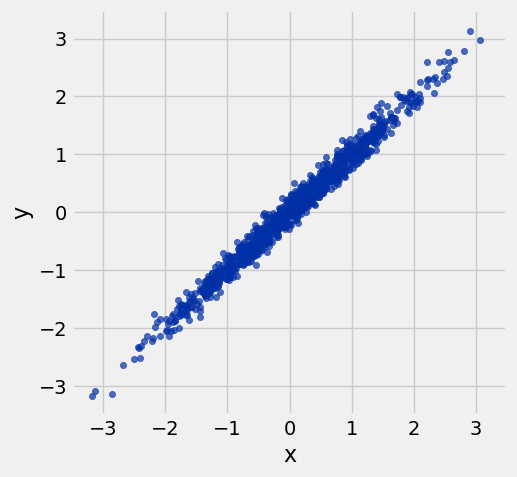

In [21]:
example.scatter('x', 'y')
resize_window()

In [22]:
#Nearest neighbor prediction.

def nn_prediction_example(x_val):
    """ Predicts y-value for x based on the example table. Nearest Neighbor """
    neighbors = example.where('x', are.between(x_val - .25, x_val + .25))
    return np.mean(neighbors.column('y'))   

In [23]:
# COMPLETE: Use the function to predict the y-value from an x-value of -2.25.

nn_prediction_example(-2.25)

-2.1476337989800522

In [24]:
# COMPLETE: Add the column of the predicted y-values to the example table. 
example = example.with_column('Predicted y', example.apply(nn_prediction_example, 'x'))
example.show(3)

x,y,Predicted y
0.0912047,-0.0680119,0.104202
1.09128,1.04391,1.05235
-1.94697,-1.88316,-1.85456


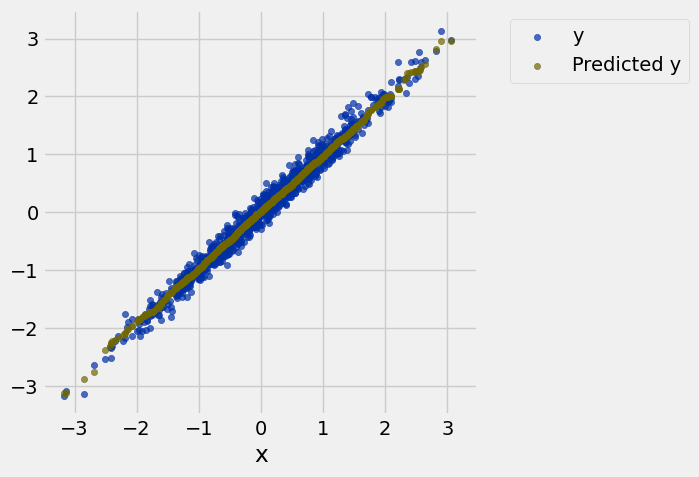

In [26]:
# Show the plotted line of predicted values.

example.scatter('x')
resize_window()

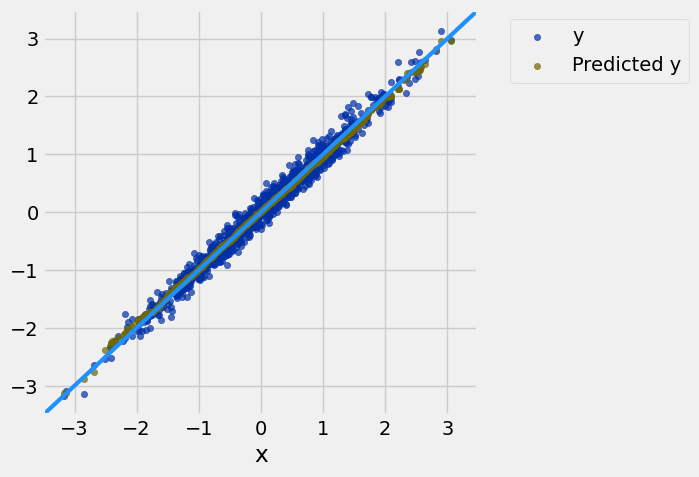

In [27]:
# Same graph overlayed with a line of slope=1.
example.scatter('x')
draw_line(slope=1)
resize_window()

### Let's run through the same process with different r values. 

### When r = 0.

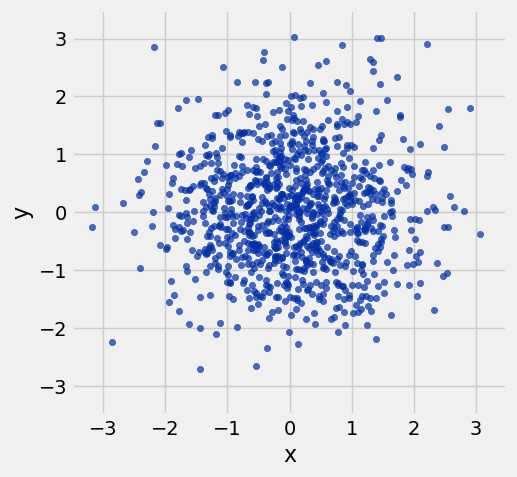

In [28]:
example = r_table(0)
example.scatter('x', 'y')
resize_window()

In [29]:
example = example.with_columns(
    'Predicted y', 
    example.apply(nn_prediction_example, 'x'))

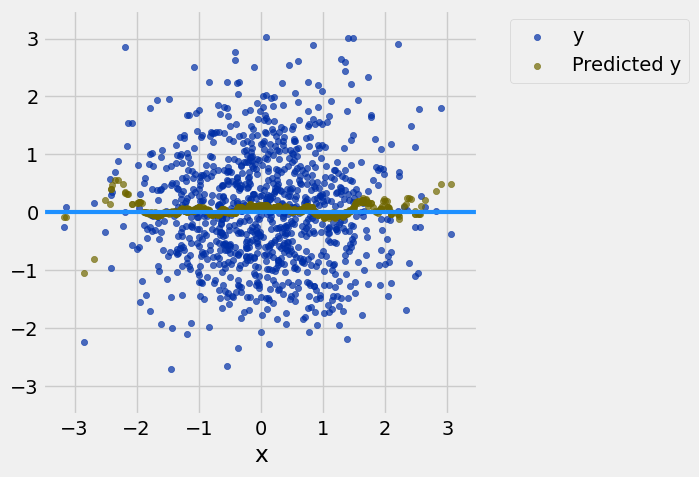

In [30]:
example.scatter('x')
draw_line(slope = 0)
resize_window()

### When r = 0.5.

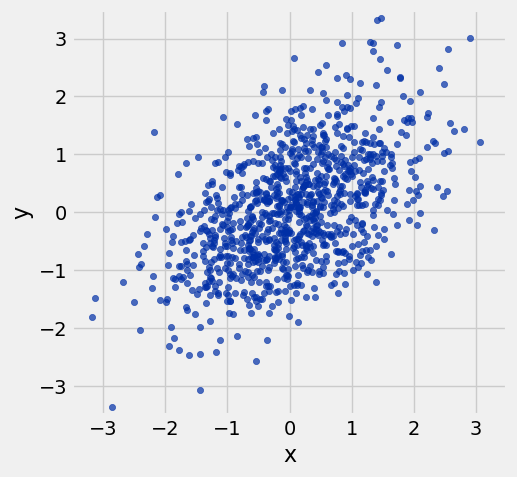

In [31]:
example = r_table(0.5)
example.scatter('x', 'y')
resize_window()

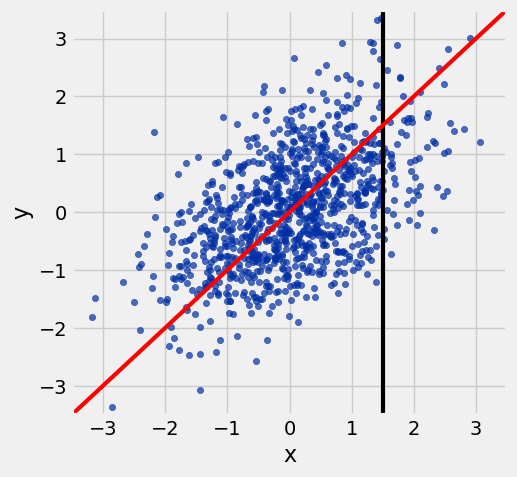

In [33]:
# What would you predict if x was 1.5?
example = r_table(0.5)
example.scatter('x', 'y')
resize_window()
draw_vertical_line(1.5)
draw_line(slope=1, intercept=0, color='red')

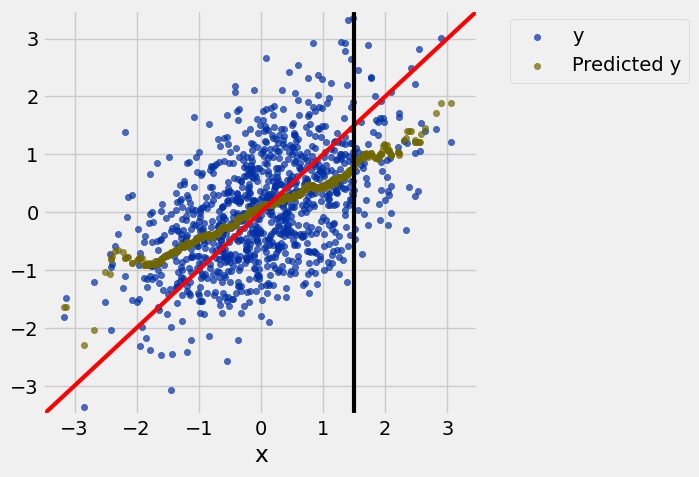

In [34]:
example = example.with_column('Predicted y', example.apply(nn_prediction_example, 'x'))
example.scatter('x')
draw_line(slope=1, color='red')
draw_vertical_line(1.5)
resize_window()

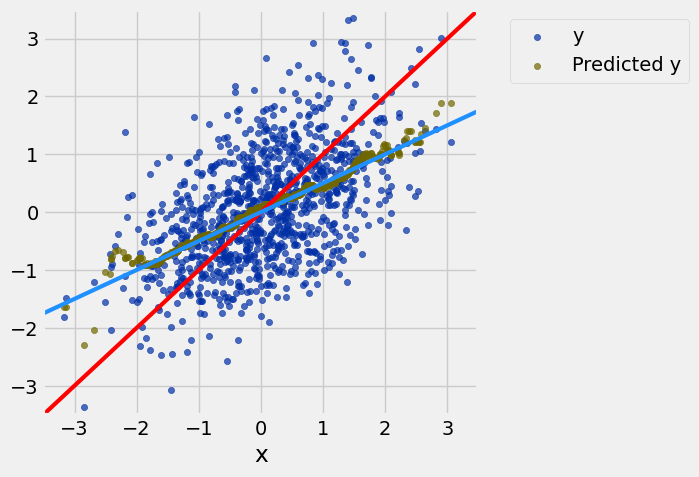

In [35]:
example.scatter('x')
draw_line(slope=1, intercept=0, color='red')
draw_line(slope=0.5, intercept=0)
resize_window()

### When r = 0.7.

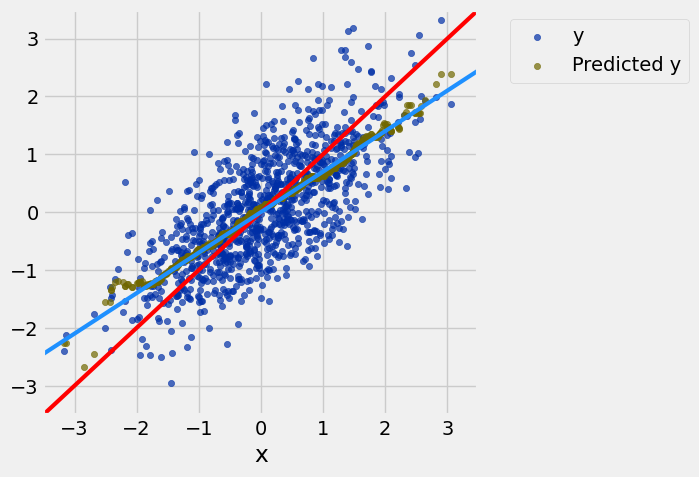

In [36]:
example = r_table(0.7)
example = example.with_column('Predicted y', example.apply(nn_prediction_example, 'x'))
example.scatter('x')
draw_line(slope=1, intercept=0, color='red')
draw_line(slope=0.7, intercept=0, color='dodgerblue')
resize_window()

## Linear regression: defining the line

Linear regression creates a model that defines the relationship between two variables. 

When r is in standard units, the line that defines the model is $y=mx$</br>
Where $m$, the slope, is equal to $r$ and the y-intercept, $b$, is equal to zero.

In [37]:
# Copy-pasted from above
def standard_units(x):
    """ Converts an array x to standard units """
    return (x - np.mean(x)) / np.std(x)

def correlation(t, x, y):
    """ Computes correlation: t is a table, and x and y are column names """
    x_su = standard_units(t.column(x))
    y_su = standard_units(t.column(y))
    return np.mean(x_su * y_su)


In [38]:
#Slope of data. 
#What is the standard deviation of normalized data?
def slope(t, x, y):
    """ Computes the slope of the regression line, like correlation above """
    r = correlation(t, x, y)
    y_sd = np.std(t.column(y))
    x_sd = np.std(t.column(x))
    return r * y_sd / x_sd


In [39]:
#Slope of data
#what is the mean of normalized data?

def intercept(t, x, y):
    """ Computes the intercept of the regression line, like slope above """
    x_mean = np.mean(t.column(x))
    y_mean = np.mean(t.column(y))
    return y_mean - slope(t, x, y)*x_mean

In [42]:
example = r_table(0.5)
slope(example, 'x', 'y')

0.50226382816259152

## Heights Data and Regression Line

When the data is not standardized, the model will follow the defintion of a line $y=mx+b$.</br>
Where $m$, the slope is equal to $\dfrac{r*y_{SD}}{x_{SD}}$</br>
and $b$, the y-intercept is equal to $y_{mean} - slope*x_{mean}$

In [43]:
# Note: Child heights are the **adult** heights of children in a family
families = Table.read_table('family_heights.csv')

parent_avgs = (families.column('father') + families.column('mother'))/2
heights = Table().with_columns(
    'Parent Average', parent_avgs,
    'Child', families.column('child'),
)
heights.show(5)

Parent Average,Child
72.75,73.2
72.75,69.2
72.75,69
72.75,69
71,73.5


In [44]:
def nn_prediction_height(p_avg):
    """Predict the height of a child whose parents have a parent average height of p_avg.
    
    The prediction is the average height of the children whose parent average height is
    in the range p_avg plus or minus 0.5.
    """
    
    close_points = heights.where('Parent Average', are.between(p_avg-0.5, p_avg + 0.5))
    return np.average(close_points.column('Child')) 

In [45]:
heights_with_predictions = heights.with_column(
    'Nearest neighbor prediction', 
    heights.apply(nn_prediction_height, 'Parent Average'))
heights_with_predictions.show(5)

Parent Average,Child,Nearest neighbor prediction
72.75,73.2,70.1
72.75,69.2,70.1
72.75,69,70.1
72.75,69,70.1
71,73.5,70.4158


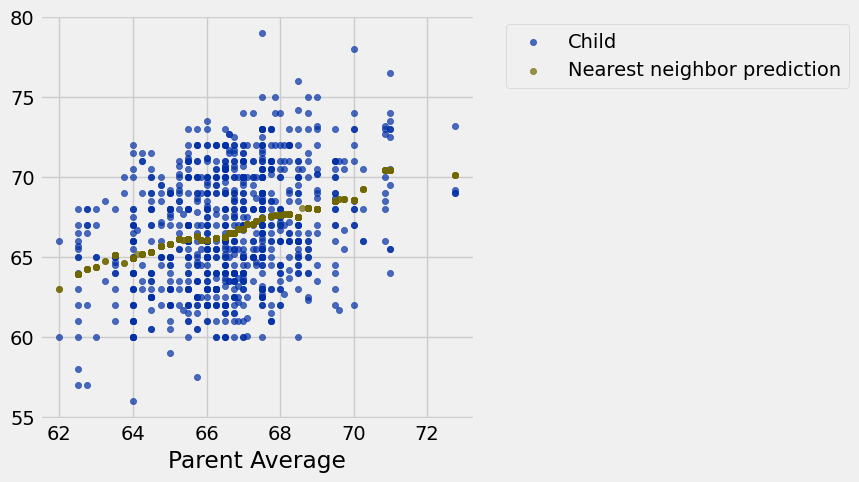

In [46]:
# COMPLETE: Show a scatter of the Parent Averages.

heights_with_predictions.scatter('Parent Average')

In [47]:
predicted_heights_slope = slope(heights, 'Parent Average', 'Child')
predicted_heights_intercept = intercept(heights, 'Parent Average', 'Child')
[predicted_heights_slope, predicted_heights_intercept]

[0.66449526235258838, 22.461839955758798]

***QUESTION: How would you write the information found in the format of a linear regression model? Hint use LaTeX.***

$y = 0.66x + 22.5$

***QUESTION: What is this calculating and what is the input?***

***QUESTION: Does the y-intercept make sense as an actual data point?***


In [49]:
# COMPLETE: Use the model to create a Regression Prediction column. 
heights_with_predictions = heights_with_predictions.with_column(
    'Regression Prediction', 
    predicted_heights_slope * heights.column('Parent Average') + predicted_heights_intercept
)
heights_with_predictions

Parent Average,Child,Nearest neighbor prediction,Regression Prediction
72.75,73.2,70.1,70.8039
72.75,69.2,70.1,70.8039
72.75,69,70.1,70.8039
72.75,69,70.1,70.8039
71,73.5,70.4158,69.641
71,72.5,70.4158,69.641
71,65.5,70.4158,69.641
71,65.5,70.4158,69.641
69.5,71,68.5025,68.6443
69.5,68,68.5025,68.6443


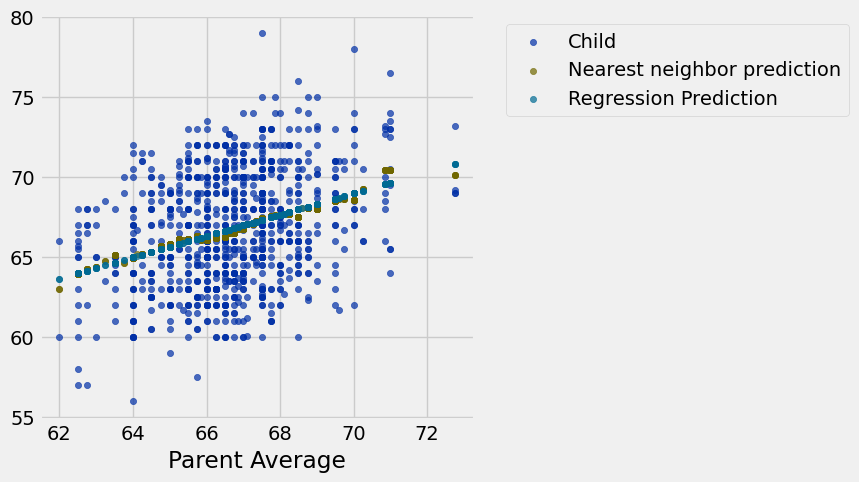

In [50]:
heights_with_predictions.scatter('Parent Average')


In [51]:
# Create a table that shows the
Standard_Heights = Table().with_columns(
    'Parent Average',  standard_units(heights.column('Parent Average')), 
    'Child', standard_units(heights.column('Child'))
    )
Standard_Heights

Parent Average,Child
3.51798,1.80416
3.51798,0.686005
3.51798,0.630097
3.51798,0.630097
2.50985,1.88802
2.50985,1.60848
2.50985,-0.348285
2.50985,-0.348285
1.64573,1.18917
1.64573,0.350559


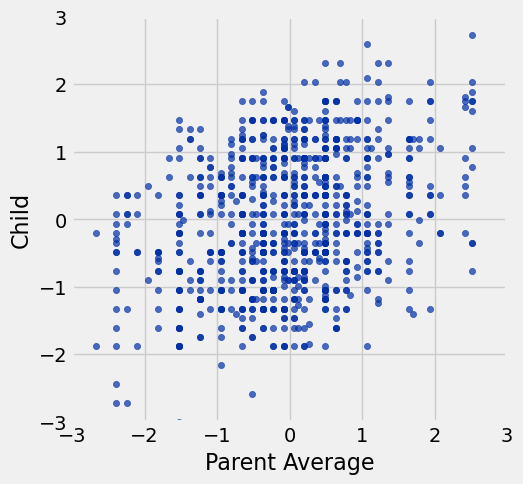

In [52]:
Standard_Heights.scatter(0, 1)
plots.xlim(-3, 3)
plots.ylim(-3, 3);

In [53]:
predicted_Sheights_slope = slope(Standard_Heights, 'Parent Average', 'Child')
predicted_Sheights_intercept = intercept(Standard_Heights, 'Parent Average', 'Child')
[predicted_Sheights_slope, predicted_Sheights_intercept]

[0.32244267720033076, 2.5461859317241727e-15]

***QUESTION: How would you write the information found in the format of a linear regression model?***

$y = 0.32x$

In [54]:
correlation(Standard_Heights, 'Parent Average', 'Child')

0.32244267720033076

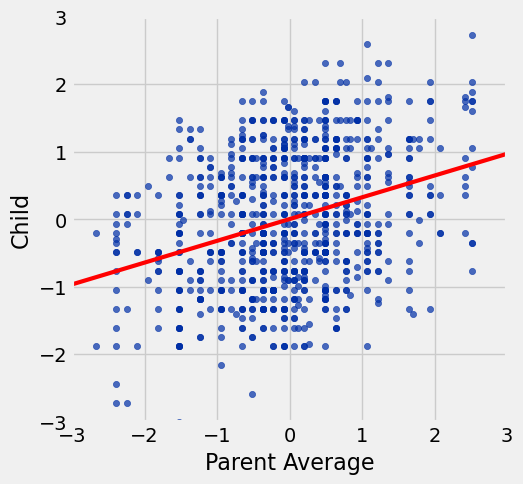

In [55]:
Standard_Heights.scatter(0, 1)
draw_line(slope=predicted_Sheights_slope, intercept=predicted_Sheights_intercept, color='red')
plots.xlim(-3, 3)
plots.ylim(-3, 3);